# 03 Experiments

Цель: сравнение моделей и анализ итоговой таблицы экспериментов

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path('..')
exp_path = ROOT / 'report' / 'experiments.csv'
exp = pd.read_csv(exp_path)
exp

,model,feature_set,val_mae,val_rmse,test_mae,test_rmse
0,xgb_small,full_features,15.609031,22.845724,22.346823,31.815831
1,xgboost,full_features,15.970151,24.729691,23.431665,34.313256
2,random_forest,full_features,16.540999,25.223770,23.213570,33.847536
3,rf_200,full_features,16.712604,25.448813,23.335223,33.897126
4,baseline_linear,full_features,37.083122,49.153719,35.808042,46.753875
5,ridge,full_features,37.309061,49.574720,35.759471,46.809773
6,knn,full_features,45.472015,58.807153,68.175265,90.510881
7,baseline_raw_linear,raw_only,114.783123,139.735550,137.173501,167.524804


In [2]:
exp.sort_values('val_mae').reset_index(drop=True)

,model,feature_set,val_mae,val_rmse,test_mae,test_rmse
0,xgb_small,full_features,15.609031,22.845724,22.346823,31.815831
1,xgboost,full_features,15.970151,24.729691,23.431665,34.313256
2,random_forest,full_features,16.540999,25.223770,23.213570,33.847536
3,rf_200,full_features,16.712604,25.448813,23.335223,33.897126
4,baseline_linear,full_features,37.083122,49.153719,35.808042,46.753875
5,ridge,full_features,37.309061,49.574720,35.759471,46.809773
6,knn,full_features,45.472015,58.807153,68.175265,90.510881
7,baseline_raw_linear,raw_only,114.783123,139.735550,137.173501,167.524804


In [3]:
best = exp.sort_values('val_mae').iloc[0]
print('best model:', best['model'])
print('feature_set:', best['feature_set'])
print('val_mae:', best['val_mae'])
print('test_mae:', best['test_mae'])

best model: xgb_small
feature_set: full_features
val_mae: 15.609031470584087
test_mae: 22.34682349722176


Полное обучение и пересчёт таблицы выполняется скриптом `src/modeling.py`.

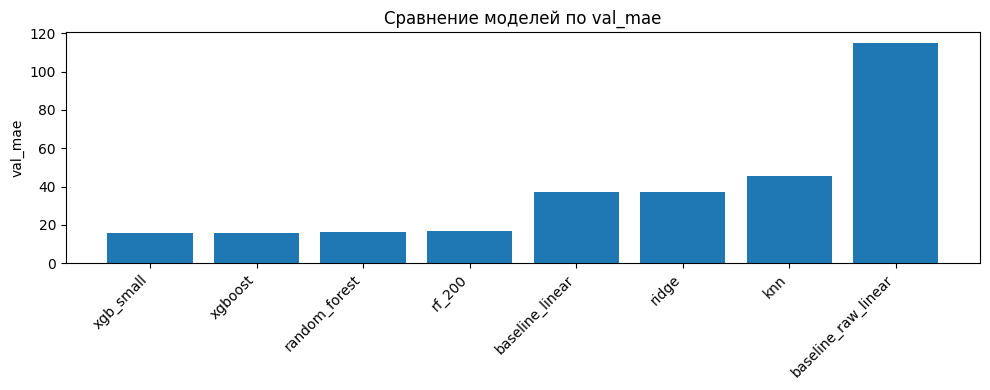

In [4]:
import matplotlib.pyplot as plt

view = exp.sort_values('val_mae').copy()
plt.figure(figsize=(10, 4))
plt.bar(view['model'], view['val_mae'])
plt.xticks(rotation=45, ha='right')
plt.title('Сравнение моделей по val_mae')
plt.ylabel('val_mae')
plt.tight_layout()
plt.show()

`xgb_small` дает лучший `val_mae`, а `baseline_raw_linear` сильно хуже, что также подтверждает важность feature engineering

In [5]:
from pathlib import Path
import json

ROOT = Path('..')
best_info = json.loads((ROOT / 'report' / 'best_model_info.json').read_text(encoding='utf-8'))
best_info

{'best_model': 'xgb_small', 'selection_metric': 'val_mae'}

In [6]:
exp.groupby('feature_set')[['val_mae', 'test_mae']].mean().sort_values('val_mae')

,val_mae,test_mae
feature_set,,
full_features,26.385283,33.152866
raw_only,114.783123,137.173501


In [7]:
cmp = exp[['model', 'val_mae', 'test_mae']].sort_values('val_mae').reset_index(drop=True)
cmp

,model,val_mae,test_mae
0,xgb_small,15.609031,22.346823
1,xgboost,15.970151,23.431665
2,random_forest,16.540999,23.213570
3,rf_200,16.712604,23.335223
4,baseline_linear,37.083122,35.808042
5,ridge,37.309061,35.759471
6,knn,45.472015,68.175265
7,baseline_raw_linear,114.783123,137.173501


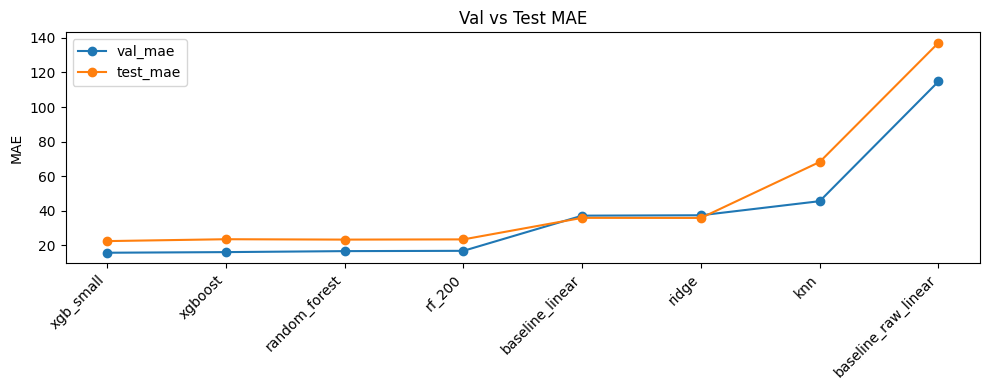

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(cmp['model'], cmp['val_mae'], marker='o', label='val_mae')
plt.plot(cmp['model'], cmp['test_mae'], marker='o', label='test_mae')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.title('Val vs Test MAE')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
cmp['generalization_gap'] = cmp['test_mae'] - cmp['val_mae']
cmp[['model', 'generalization_gap']].sort_values('generalization_gap')

,model,generalization_gap
5,ridge,-1.549590
4,baseline_linear,-1.275080
3,rf_200,6.622619
2,random_forest,6.672571
0,xgb_small,6.737792
1,xgboost,7.461513
7,baseline_raw_linear,22.390378
6,knn,22.703251


Вывод: по `val_mae` лучше `xgb_small`, при этом отрыв от остальных ансамблей устойчивый, а baseline без FE сильно проигрывает

## Дальше

- Углубить подбор гиперпараметров: увеличить число конфигураций для XGBoost/RandomForest
- Добавить проверку стабильности
- Сравнить качество и время обучения, чтобы выбрать модель не только по MAE, но и по практичности